# 1. Import and Install Dependencies

In [2]:
%pip install tensorflow opencv-python mediapipe scikit-learn matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import cv2
import numpy as np
import os
from matplotlib import pyplot as plt
import time
import mediapipe as mp
import json

# 2. Keypoints using MP Holistic

In [2]:
mp_holistic = mp.solutions.holistic # Holistic model
mp_drawing = mp.solutions.drawing_utils # Drawing utilities

In [3]:
def mediapipe_detection(image, model):
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB) # COLOR CONVERSION BGR 2 RGB
    image.flags.writeable = False                  # Image is no longer writeable
    results = model.process(image)                 # Make prediction
    image.flags.writeable = True                   # Image is now writeable 
    image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR) # COLOR COVERSION RGB 2 BGR
    return image, results

In [4]:
def draw_landmarks(image, results):
    # mp_drawing.draw_landmarks(image, results.face_landmarks, mp_holistic.FACEMESH_TESSELATION) # Draw face connections
    mp_drawing.draw_landmarks(image, results.pose_landmarks, mp_holistic.POSE_CONNECTIONS) # Draw pose connections
    mp_drawing.draw_landmarks(image, results.left_hand_landmarks, mp_holistic.HAND_CONNECTIONS) # Draw left hand connections
    mp_drawing.draw_landmarks(image, results.right_hand_landmarks, mp_holistic.HAND_CONNECTIONS) # Draw right hand connections

In [5]:
def draw_styled_landmarks(image, results):
    # Draw face connections
    # mp_drawing.draw_landmarks(image, results.face_landmarks, mp_holistic.FACEMESH_TESSELATION, 
    #                          mp_drawing.DrawingSpec(color=(80,110,10), thickness=1, circle_radius=1), 
    #                          mp_drawing.DrawingSpec(color=(80,256,121), thickness=1, circle_radius=1)
    #                          ) 
    # Draw pose connections
    mp_drawing.draw_landmarks(image, results.pose_landmarks, mp_holistic.POSE_CONNECTIONS,
                             mp_drawing.DrawingSpec(color=(80,22,10), thickness=2, circle_radius=4), 
                             mp_drawing.DrawingSpec(color=(80,44,121), thickness=2, circle_radius=2)
                             ) 
    # Draw left hand connections
    mp_drawing.draw_landmarks(image, results.left_hand_landmarks, mp_holistic.HAND_CONNECTIONS, 
                             mp_drawing.DrawingSpec(color=(121,22,76), thickness=2, circle_radius=4), 
                             mp_drawing.DrawingSpec(color=(121,44,250), thickness=2, circle_radius=2)
                             ) 
    # Draw right hand connections  
    mp_drawing.draw_landmarks(image, results.right_hand_landmarks, mp_holistic.HAND_CONNECTIONS, 
                             mp_drawing.DrawingSpec(color=(245,117,66), thickness=2, circle_radius=4), 
                             mp_drawing.DrawingSpec(color=(245,66,230), thickness=2, circle_radius=2)
                             ) 

In [6]:
cap = cv2.VideoCapture(0)
# Set mediapipe model 
with mp_holistic.Holistic(min_detection_confidence=0.5, min_tracking_confidence=0.5) as holistic:
    while cap.isOpened():

        # Read feed
        ret, frame = cap.read()

        # Make detections
        image, results = mediapipe_detection(frame, holistic)
        print(results)
        
        # Draw landmarks
        draw_styled_landmarks(image, results)

        # Show to screen
        cv2.imshow('OpenCV Feed', image)

        # Break gracefully
        if cv2.waitKey(10) & 0xFF == ord('q'):
            break
    cap.release()
    cv2.destroyAllWindows()

<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.soluti

In [7]:
draw_landmarks(frame, results)

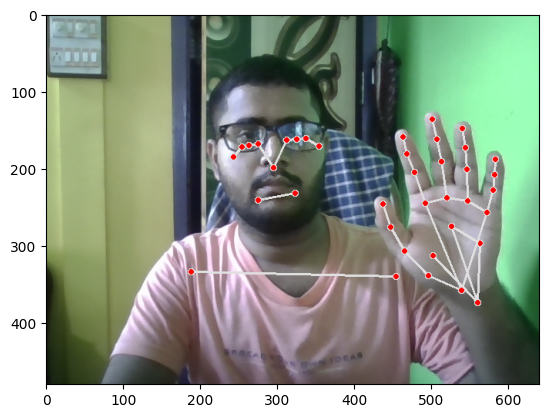

In [8]:
plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))

# 3. Extract Keypoint Values

In [9]:
if results.face_landmarks:
    print("Face landmarks:", len(results.face_landmarks.landmark))

if results.pose_landmarks:
    print("Pose landmarks:", len(results.pose_landmarks.landmark))

if results.left_hand_landmarks:
    print("Left hand landmarks:", len(results.left_hand_landmarks.landmark))

if results.right_hand_landmarks:
    print("Right hand landmarks:", len(results.right_hand_landmarks.landmark))


Face landmarks: 468
Pose landmarks: 33
Left hand landmarks: 21


In [10]:
pose = []
for res in results.pose_landmarks.landmark:
    test = np.array([res.x, res.y, res.z, res.visibility])
    pose.append(test)

In [11]:
pose = np.array([[res.x, res.y, res.z, res.visibility] for res in results.pose_landmarks.landmark]).flatten() if results.pose_landmarks else np.zeros(132)
face = np.array([[res.x, res.y, res.z] for res in results.face_landmarks.landmark]).flatten() if results.face_landmarks else np.zeros(1404)
lh = np.array([[res.x, res.y, res.z] for res in results.left_hand_landmarks.landmark]).flatten() if results.left_hand_landmarks else np.zeros(21*3)
rh = np.array([[res.x, res.y, res.z] for res in results.right_hand_landmarks.landmark]).flatten() if results.right_hand_landmarks else np.zeros(21*3)

In [12]:
def extract_keypoints(results):
    pose = np.array([[res.x, res.y, res.z, res.visibility] for res in results.pose_landmarks.landmark]).flatten() if results.pose_landmarks else np.zeros(33*4)
    face = np.array([[res.x, res.y, res.z] for res in results.face_landmarks.landmark]).flatten() if results.face_landmarks else np.zeros(468*3)
    lh = np.array([[res.x, res.y, res.z] for res in results.left_hand_landmarks.landmark]).flatten() if results.left_hand_landmarks else np.zeros(21*3)
    rh = np.array([[res.x, res.y, res.z] for res in results.right_hand_landmarks.landmark]).flatten() if results.right_hand_landmarks else np.zeros(21*3)
    return np.concatenate([pose, face, lh, rh])

In [13]:
result_test = extract_keypoints(results)

In [14]:
result_test

array([ 0.46099943,  0.41490331, -0.80023259, ...,  0.        ,
        0.        ,  0.        ])

In [15]:
np.save('0', result_test)

In [16]:
np.load('0.npy')

array([ 0.46099943,  0.41490331, -0.80023259, ...,  0.        ,
        0.        ,  0.        ])

# 4. Setup Folders for Collection

In [17]:
import json

# Path for exported data, numpy arrays
DATA_PATH = os.path.join('MP_Data_gloss') 
VIDEO_PATH = os.path.join('../../datasets/ISL_Gifs')
GLOSS_PATH = os.path.join('../../datasets/invGlossList.json')

# Actions that we try to detect
with open(GLOSS_PATH, 'r') as f:
    gloss = json.load(f)
    
actions = np.array(list(gloss.keys()))
print(f"Actions: {actions}")

# Thirty videos worth of data
no_sequences = 30

# Videos are going to be 30 frames in length
sequence_length = 30

# Folder start
start_folder = 1

Actions: ['a' 'address' 'ahemdabad' 'all' 'any questions' 'are you angry'
 'are you hungry' 'assam' 'august' 'b' 'banana' 'banaras' 'banglore'
 'be careful' 'bridge' 'c' 'cat' 'christmas' 'church' 'cilinic' 'd'
 'dasara' 'december' 'did you finish homework' 'do you have money'
 'do you want something to drink' 'do you watch tv' 'dont worry' 'e' 'f'
 'flower is beautiful' 'g' 'good afternoon' 'good morning' 'good question'
 'grapes' 'h' 'hello' 'hindu' 'hyderabad' 'i am a clerk' 'i am fine'
 'i am sorry' 'i am thinking' 'i am tired' 'i go to a theatre'
 'i had to say something but i forgot' 'i like pink colour'
 'i love to shop' 'job' 'july' 'june' 'karnataka' 'kerala' 'krishna' 'l'
 'lets go for lunch' 'm' 'mango' 'may' 'mile' 'mumbai' 'nagpur'
 'nice to meet you' 'open the door' 'p' 'pakistan' 'please call me later'
 'police station' 'post office' 'pune' 'punjab' 'saturday'
 'shall i help you' 'shall we go together tommorow' 'shop'
 'sign language interpreter' 'sit down' 'stand up' 't

In [18]:
for action in actions: 
    if not os.path.exists(os.path.join(DATA_PATH, action)):
        os.makedirs(os.path.join(DATA_PATH, action))
    dirmax = np.max(np.array(os.listdir(os.path.join(DATA_PATH, action))).astype(int)) if os.listdir(os.path.join(DATA_PATH, action)) else 0
    for sequence in range(1,no_sequences+1):
        try: 
            os.makedirs(os.path.join(DATA_PATH, action, str(dirmax+sequence)))
        except:
            pass

# 5. Collect Keypoint Values for Training and Testing

### Live video feed

In [ ]:
# cap = cv2.VideoCapture(0)

# action_index = 0
# stop_all = False

# with mp_holistic.Holistic(min_detection_confidence=0.5, min_tracking_confidence=0.5) as holistic:
    
#     while action_index < len(actions) and not stop_all:
#         action = actions[action_index]
#         print(f"Starting action: {action}")

#         for sequence in range(start_folder, start_folder + no_sequences):
#             for frame_num in range(sequence_length):
#                 ret, frame = cap.read()
#                 if not ret:
#                     continue

#                 # Make detections
#                 image, results = mediapipe_detection(frame, holistic)

#                 # Draw landmarks
#                 draw_styled_landmarks(image, results)

#                 # Display status text
#                 if frame_num == 0:
#                     cv2.putText(image, 'STARTING COLLECTION', (120,200), 
#                                 cv2.FONT_HERSHEY_SIMPLEX, 1, (0,255,0), 4, cv2.LINE_AA)
#                     cv2.putText(image, f'Collecting for {action} Video {sequence}', (15,12), 
#                                 cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,0,255), 1, cv2.LINE_AA)
#                     cv2.imshow('OpenCV Feed', image)
#                     cv2.waitKey(500)
#                 else:
#                     cv2.putText(image, f'Collecting for {action} Video {sequence}', (15,12), 
#                                 cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,0,255), 1, cv2.LINE_AA)
#                     cv2.imshow('OpenCV Feed', image)

#                 # Export keypoints
#                 keypoints = extract_keypoints(results)
#                 npy_path = os.path.join(DATA_PATH, action, str(sequence), str(frame_num))
#                 if not os.path.exists(os.path.dirname(npy_path)):
#                     os.makedirs(os.path.dirname(npy_path))
#                 if not os.path.exists(npy_path + '.npy'):
#                     np.save(npy_path, keypoints)

#                 # Handle key presses
#                 key = cv2.waitKey(10) & 0xFF
#                 if key == ord('q'):
#                     print("Frame loop break (q pressed).")
#                     break  # exit current sequence early
#                 elif key == 27:  # ESC
#                     print("ESC pressed. Stopping all collection.")
#                     stop_all = True
#                     break
#                 elif stop_all or key in [ord('q'), 83, 2555904]:
#                     break
#             if key == 83 or key == 2555904:  # Right arrow key
#                 print("Right arrow pressed. Skipping to next action.")
#                 break

#         action_index += 1

# cap.release()
# cv2.destroyAllWindows()


Starting action: hello
ESC pressed. Stopping all collection.


### From dataset

In [19]:
# cap = cv2.VideoCapture(0)

action_index = 0
stop_all = False

with mp_holistic.Holistic(min_detection_confidence=0.5, min_tracking_confidence=0.5) as holistic:
    
    while action_index < len(actions) and not stop_all:
        action = actions[action_index]
        gloss_vid = gloss[action][0]
        action_vid_path = os.path.join(VIDEO_PATH,gloss_vid + '.gif')
        if not os.path.exists(action_vid_path):
            print(f"Skipping path ==> {action_vid_path}")
            action_index += 1
            continue        
        cap = cv2.VideoCapture(action_vid_path)

        
        print(f"Starting action: {action}")

        for sequence in range(start_folder, start_folder + no_sequences):
            for frame_num in range(sequence_length):
                ret, frame = cap.read()
                if not ret:
                    continue

                # Make detections
                image, results = mediapipe_detection(frame, holistic)

                # Draw landmarks
                draw_styled_landmarks(image, results)

                # Display status text
                if frame_num == 0:
                    cv2.putText(image, 'STARTING COLLECTION', (120,200), 
                                cv2.FONT_HERSHEY_SIMPLEX, 1, (0,255,0), 4, cv2.LINE_AA)
                    cv2.putText(image, f'Collecting for {action} Video {sequence}', (15,12), 
                                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,0,255), 1, cv2.LINE_AA)
                    cv2.imshow('OpenCV Feed', image)
                    cv2.waitKey(500)
                else:
                    cv2.putText(image, f'Collecting for {action} Video {sequence}', (15,12), 
                                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,0,255), 1, cv2.LINE_AA)
                    cv2.imshow('OpenCV Feed', image)

                # Export keypoints
                keypoints = extract_keypoints(results)
                npy_path = os.path.join(DATA_PATH, action, str(sequence), str(frame_num))
                if not os.path.exists(os.path.dirname(npy_path)):
                    os.makedirs(os.path.dirname(npy_path))
                if not os.path.exists(npy_path + '.npy'):
                    np.save(npy_path, keypoints)

                # Handle key presses
                key = cv2.waitKey(10) & 0xFF
                if key == ord('q'):
                    print("Frame loop break (q pressed).")
                    break  # exit current sequence early
                elif key == 27:  # ESC
                    print("ESC pressed. Stopping all collection.")
                    stop_all = True
                    break
                elif stop_all or key in [ord('q'), 83, 2555904]:
                    break
            if key == 83 or key == 2555904:  # Right arrow key
                print("Right arrow pressed. Skipping to next action.")
                break

        action_index += 1

cap.release()
cv2.destroyAllWindows()


Starting action: a
Starting action: address
Starting action: ahemdabad
Starting action: all
Starting action: any questions
Starting action: are you angry
Starting action: are you hungry
Starting action: assam
Starting action: august
Starting action: b
Starting action: banana
Starting action: banaras
Starting action: banglore
Starting action: be careful
Starting action: bridge
Starting action: c
Starting action: cat
Starting action: christmas
Starting action: church
Starting action: cilinic
Starting action: d
Starting action: dasara
Starting action: december
Starting action: did you finish homework
Starting action: do you have money
Starting action: do you want something to drink
Starting action: do you watch tv
Starting action: dont worry
Starting action: e
Starting action: f
Starting action: flower is beautiful
Starting action: g
Starting action: good afternoon
Starting action: good morning
Starting action: good question
Starting action: grapes
Starting action: h
Starting action: hell

In [20]:
cap.release()
cv2.destroyAllWindows()

# 6. Preprocess Data and Create Labels and Features

In [21]:
from sklearn.model_selection import train_test_split
from keras.utils import to_categorical

In [22]:
label_map = {label:num for num, label in enumerate(actions)}

In [23]:
label_map

{'a': 0,
 'address': 1,
 'ahemdabad': 2,
 'all': 3,
 'any questions': 4,
 'are you angry': 5,
 'are you hungry': 6,
 'assam': 7,
 'august': 8,
 'b': 9,
 'banana': 10,
 'banaras': 11,
 'banglore': 12,
 'be careful': 13,
 'bridge': 14,
 'c': 15,
 'cat': 16,
 'christmas': 17,
 'church': 18,
 'cilinic': 19,
 'd': 20,
 'dasara': 21,
 'december': 22,
 'did you finish homework': 23,
 'do you have money': 24,
 'do you want something to drink': 25,
 'do you watch tv': 26,
 'dont worry': 27,
 'e': 28,
 'f': 29,
 'flower is beautiful': 30,
 'g': 31,
 'good afternoon': 32,
 'good morning': 33,
 'good question': 34,
 'grapes': 35,
 'h': 36,
 'hello': 37,
 'hindu': 38,
 'hyderabad': 39,
 'i am a clerk': 40,
 'i am fine': 41,
 'i am sorry': 42,
 'i am thinking': 43,
 'i am tired': 44,
 'i go to a theatre': 45,
 'i had to say something but i forgot': 46,
 'i like pink colour': 47,
 'i love to shop': 48,
 'job': 49,
 'july': 50,
 'june': 51,
 'karnataka': 52,
 'kerala': 53,
 'krishna': 54,
 'l': 55,
 '

In [24]:
sequences, labels = [], []

# Label map for indexing
label_map = {label: idx for idx, label in enumerate(actions)}

for action in actions:
    action_path = os.path.join(DATA_PATH, action)

    sequence_dirs = [d for d in os.listdir(action_path) if d.isdigit()]
    if not sequence_dirs:
        print(f"No sequence folder found for action: {action}")
        continue

    for sequence in sequence_dirs:
        sequence_path = os.path.join(action_path, sequence)
        frame_files = sorted([f for f in os.listdir(sequence_path) if f.endswith('.npy')],
                             key=lambda x: int(x.replace('.npy', '')))

        if not frame_files:
            print(f"Skipping {action}/{sequence}: No frames found.")
            continue

        window = []
        for frame_name in frame_files:
            frame_path = os.path.join(sequence_path, frame_name)
            res = np.load(frame_path)
            window.append(res)

        # Pad with last frame if less than required
        if len(window) < sequence_length:
            last_frame = window[-1]
            while len(window) < sequence_length:
                window.append(last_frame.copy())

        # Safety check
        if len(window) == sequence_length:
            sequences.append(window)
            labels.append(label_map[action])
        else:
            print(f"Unexpected error padding {action}/{sequence}")


Skipping a/10: No frames found.
Skipping a/11: No frames found.
Skipping a/12: No frames found.
Skipping a/13: No frames found.
Skipping a/14: No frames found.
Skipping a/15: No frames found.
Skipping a/16: No frames found.
Skipping a/17: No frames found.
Skipping a/18: No frames found.
Skipping a/19: No frames found.
Skipping a/2: No frames found.
Skipping a/20: No frames found.
Skipping a/21: No frames found.
Skipping a/22: No frames found.
Skipping a/23: No frames found.
Skipping a/24: No frames found.
Skipping a/25: No frames found.
Skipping a/26: No frames found.
Skipping a/27: No frames found.
Skipping a/28: No frames found.
Skipping a/29: No frames found.
Skipping a/3: No frames found.
Skipping a/30: No frames found.
Skipping a/31: No frames found.
Skipping a/32: No frames found.
Skipping a/33: No frames found.
Skipping a/34: No frames found.
Skipping a/35: No frames found.
Skipping a/36: No frames found.
Skipping a/37: No frames found.
Skipping a/38: No frames found.
Skipping a

In [25]:
X = np.array(sequences)
y = np.array(labels)

print("All sequences loaded.")
print("X shape:", X.shape)  
print("y shape:", y.shape)  


All sequences loaded.
X shape: (139, 30, 1662)
y shape: (139,)


In [26]:
np.array(sequences).shape

(139, 30, 1662)

In [27]:
np.array(labels).shape

(139,)

In [28]:
X = np.array(sequences)

In [29]:
X.shape

(139, 30, 1662)

In [30]:
y = to_categorical(labels).astype(int)

In [31]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.05)

In [32]:
y_test.shape

(7, 100)

# 7. Build and Train LSTM Neural Network

In [33]:
from keras.models import Sequential
from keras.layers import LSTM, Dense
from keras.callbacks import TensorBoard

In [34]:
log_dir = os.path.join('Logs')
tb_callback = TensorBoard(log_dir=log_dir)

In [35]:
model = Sequential()
model.add(LSTM(64, return_sequences=True, activation='relu', input_shape=(30,1662)))
model.add(LSTM(128, return_sequences=True, activation='relu'))
model.add(LSTM(64, return_sequences=False, activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(32, activation='relu'))
model.add(Dense(actions.shape[0], activation='softmax'))

c:\Users\tahmi\Documents\Work\Text2Sign\t2slt\train_env\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [36]:
model.compile(optimizer='Adam', loss='categorical_crossentropy', metrics=['categorical_accuracy'])

In [ ]:
from keras.layers import LSTM, Dense, Dropout
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
from keras.optimizers import Adam

In [ ]:
model = Sequential()
# LSTM Layers with Dropout
model.add(LSTM(64, return_sequences=True, input_shape=(30, 1662)))
model.add(Dropout(0.3))

model.add(LSTM(128, return_sequences=True))
model.add(Dropout(0.3))

model.add(LSTM(64, return_sequences=False))
model.add(Dropout(0.3))

# Dense Layers
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.3))

model.add(Dense(32, activation='relu'))
model.add(Dropout(0.3))

# Output Layer (number of actions/classes)
model.add(Dense(actions.shape[0], activation='softmax'))  # or sigmoid if multilabel


In [ ]:
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',  # or 'sparse_categorical_crossentropy' if labels are integers
    metrics=['accuracy']
)

In [37]:
model.fit(X_train, y_train, epochs=2000, callbacks=[tb_callback])

Epoch 1/2000
5/5 ━━━━━━━━━━━━━━━━━━━━ 7s 72ms/step - categorical_accuracy: 0.0082 - loss: 4.6235
Epoch 2/2000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - categorical_accuracy: 0.0056 - loss: 4.6125   
Epoch 3/2000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - categorical_accuracy: 0.0000e+00 - loss: 4.6100
Epoch 4/2000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - categorical_accuracy: 0.0120 - loss: 4.5994  
Epoch 5/2000
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 129ms/step - categorical_accuracy: 0.0137 - loss: 4.5867 
Epoch 6/2000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - categorical_accuracy: 0.0120 - loss: 4.6023 
Epoch 7/2000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - categorical_accuracy: 0.0215 - loss: 4.5933
Epoch 8/2000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - categorical_accuracy: 0.0163 - loss: 4.5919 
Epoch 9/2000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - categorical_accuracy: 0.0111 - loss: 4.5915   
Epoch 10/2000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - categorical_accuracy: 0.0000e+00 - loss: 4.7130
Epoch 11/

In [38]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 64)         │       442,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 30, 128)        │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 100)            │         3,300 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,799,630 (6.87 MB)

 Trainable params: 599,876 (2.29 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,199,754 (4.58 MB)

# 8. Make Predictions

In [39]:
res = model.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 687ms/step


In [40]:
actions[np.argmax(res[4])]

'do you want something to drink'

In [41]:
actions[np.argmax(y_test[4])]

'i am thinking'

# 9. Save Weights

In [42]:
model.save('s2t_lstm_refined2.h5')

In [217]:
del model

In [14]:
model.load_weights('action.h5')

# 10. Evaluation using Confusion Matrix and Accuracy

In [33]:
from sklearn.metrics import multilabel_confusion_matrix, accuracy_score

In [41]:
yhat = model.predict(X_test)

In [42]:
ytrue = np.argmax(y_test, axis=1).tolist()
yhat = np.argmax(yhat, axis=1).tolist()

In [43]:
multilabel_confusion_matrix(ytrue, yhat)

array([[[5, 0],
        [0, 4]],

       [[5, 0],
        [0, 4]],

       [[8, 0],
        [0, 1]]], dtype=int64)

In [44]:
accuracy_score(ytrue, yhat)

1.0

# 11. Test in Real Time

In [56]:
from scipy import stats

In [15]:
colors = [(245,117,16), (117,245,16), (16,117,245)]
def prob_viz(res, actions, input_frame, colors):
    output_frame = input_frame.copy()
    for num, prob in enumerate(res):
        cv2.rectangle(output_frame, (0,60+num*40), (int(prob*100), 90+num*40), colors[num], -1)
        cv2.putText(output_frame, actions[num], (0, 85+num*40), cv2.FONT_HERSHEY_SIMPLEX, 1, (255,255,255), 2, cv2.LINE_AA)
        
    return output_frame

In [ ]:
# 1. New detection variables
sequence = []
sentence = []
predictions = []
threshold = 0.5

cap = cv2.VideoCapture(0)
# Set mediapipe model 
with mp_holistic.Holistic(min_detection_confidence=0.5, min_tracking_confidence=0.5) as holistic:
    while cap.isOpened():

        # Read feed
        ret, frame = cap.read()

        # Make detections
        image, results = mediapipe_detection(frame, holistic)
        print(results)
        
        # Draw landmarks
        draw_styled_landmarks(image, results)
        
        # 2. Prediction logic
        keypoints = extract_keypoints(results)
        sequence.append(keypoints)
        sequence = sequence[-30:]
        
        if len(sequence) == 30:
            res = model.predict(np.expand_dims(sequence, axis=0))[0]
            print(actions[np.argmax(res)])
            predictions.append(np.argmax(res))
            
            
        #3. Viz logic
            if np.unique(predictions[-10:])[0]==np.argmax(res): 
                if res[np.argmax(res)] > threshold: 
                    
                    if len(sentence) > 0: 
                        if actions[np.argmax(res)] != sentence[-1]:
                            sentence.append(actions[np.argmax(res)])
                    else:
                        sentence.append(actions[np.argmax(res)])

            if len(sentence) > 5: 
                sentence = sentence[-5:]

            # Viz probabilities
            image = prob_viz(res, actions, image, colors)
            
        cv2.rectangle(image, (0,0), (640, 40), (245, 117, 16), -1)
        cv2.putText(image, ' '.join(sentence), (3,30), 
                       cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 2, cv2.LINE_AA)
        
        # Show to screen
        cv2.imshow('OpenCV Feed', image)

        # Break gracefully
        if cv2.waitKey(10) & 0xFF == ord('q'):
            break
    cap.release()
    cv2.destroyAllWindows()